<a href="https://colab.research.google.com/github/meryambutt123-a11y/urdu-ocr-codesaviours-si26-maryam/blob/main/SI26_Week5_Maryam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Re-install a compatible version of PyTorch, transformers, and the missing tokenizers
!pip install torch>=2.2.0 torchvision torchaudio
!pip install transformers==4.35.0 sentencepiece tiktoken

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
peft 0.19.1 requires transformers, which is not installed.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Using cached transformers-4.35.0-py3-none-any.whl.metadata (123 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2

In [ ]:
!pip install --upgrade transformers huggingface-hub tokenizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 32.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [ ]:
import os
from transformers import ViTImageProcessor, RobertaTokenizer, TrOCRProcessor, VisionEncoderDecoderModel

# 1. Point directly to the folder containing your saved model
model_path = "/content/drive/MyDrive/Urdu_OCR_Project/models/trocr_urdu_raw_baseline"

# 2. Load the tokenizer and image processor (bypassing the fast-tokenizer bug)
print("Loading tokenizer and image processor...")
tokenizer = RobertaTokenizer.from_pretrained('microsoft/trocr-base-printed')
image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

# 3. Load the model
print(f"Loading model from {model_path}...")
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()

print("\n🚀 Model loaded successfully!")

Loading tokenizer and image processor...
Loading model from /content/drive/MyDrive/Urdu_OCR_Project/models/trocr_urdu_raw_baseline...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]


🚀 Model loaded successfully!


✅ Found images in the 'processed' folder!
Testing on image: signboard_6.jpg



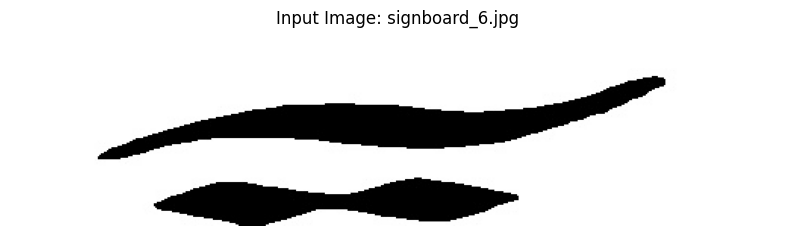


📝 Extracted Urdu Text:
ٹوٹ


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

# 1. Look inside the 'processed' (or 'raw') subfolders
base_data_folder = "/content/drive/MyDrive/Urdu_OCR_Project/data"

# Check 'processed' first, then fallback to 'raw'
for subfolder in ["processed", "raw"]:
    data_folder = os.path.join(base_data_folder, subfolder)
    all_files = os.listdir(data_folder)
    image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:
        print(f"✅ Found images in the '{subfolder}' folder!")
        break

if not image_files:
    print(f"❌ No images found in 'raw' or 'processed'.")
else:
    # Pick the first image it finds
    actual_image_name = image_files[0]
    image_path = os.path.join(data_folder, actual_image_name)
    print(f"Testing on image: {actual_image_name}\n")

    # 2. Move model to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # 3. Load the image
    image = Image.open(image_path).convert("RGB")

    # 4. Display the image in Colab
    plt.figure(figsize=(10, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Input Image: {actual_image_name}")
    plt.show()

    # 5. Preprocess for the model
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)


    # 6. Run the model to generate token IDs (with max_new_tokens fixed)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, max_new_tokens=100)

    # 7. Decode the token IDs back into readable Urdu text
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print("\n📝 Extracted Urdu Text:")
    print(generated_text)

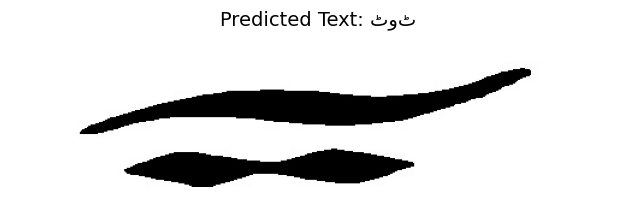

--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)


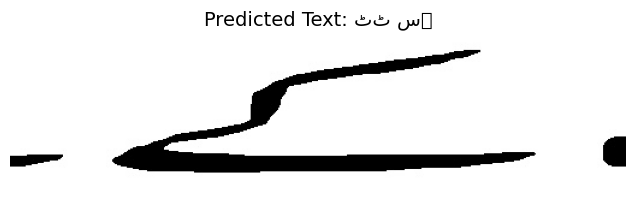

--------------------------------------------------


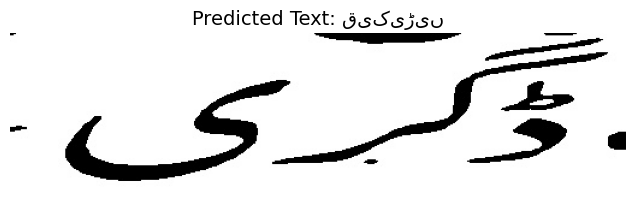

--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


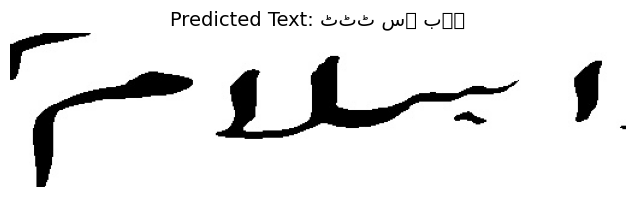

--------------------------------------------------


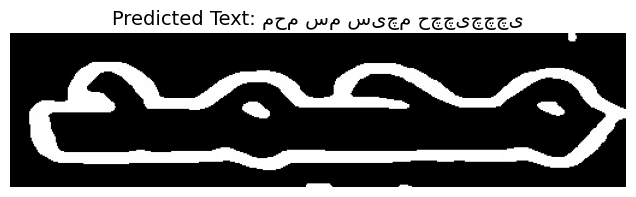

--------------------------------------------------


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

data_folder = "/content/drive/MyDrive/Urdu_OCR_Project/data/processed"
all_files = os.listdir(data_folder)
image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Take the first 5 images
batch_files = image_files[:5]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for image_name in batch_files:
    image_path = os.path.join(data_folder, image_name)
    image = Image.open(image_path).convert("RGB")

    # Preprocess and Generate
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, max_new_tokens=100)

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Display results
    plt.figure(figsize=(8, 2))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted Text: {generated_text}", fontsize=14, fontname='Nafees Nastaleeq') # Add a custom font if needed
    plt.show()
    print("-" * 50)

In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.3 MB/s eta 0:00:00


In [ ]:
import os
import torch
import pandas as pd
from PIL import Image
from jiwer import cer

# 1. Quick function to fix aspect ratio (adds white padding)
def pad_image(image):
    w, h = image.size
    target_size = max(w, h)
    padded_image = Image.new('RGB', (target_size, target_size), (255, 255, 255))
    padded_image.paste(image, (0, (target_size - h) // 2))
    return padded_image

# 2. Fix the paths and load labels (telling Pandas there is no header row)
project_root = "/content/drive/MyDrive/Urdu_OCR_Project"
labels_path = os.path.join(project_root, "data/labels.csv")

print("Loading labels...")
# header=None prevents the first row from being swallowed as column names
df = pd.read_csv(labels_path, header=None)

# Columns are just 0 and 1 now
img_col = 0
text_col = 1

predictions = []
ground_truths = []
valid_filenames = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Found {len(df)} rows in CSV. Starting batch processing...\n")

# 3. Loop through every file
for index, row in df.iterrows():
    img_name = str(row[img_col])
    true_text = str(row[text_col])

    # Combine the project root with the path listed in your CSV
    img_path = os.path.join(project_root, img_name)

    if not os.path.exists(img_path):
        continue # Skip if the image isn't found

    # Process image
    image = Image.open(img_path).convert("RGB")
    image = pad_image(image)

    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values, max_new_tokens=100)

    pred_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    predictions.append(pred_text)
    ground_truths.append(true_text)
    valid_filenames.append(img_name)

# 4. Calculate final metrics and save
print("Calculating Error Rates...")
if len(predictions) > 0:
    error_rate = cer(ground_truths, predictions)
else:
    error_rate = 0.0
    print("⚠️ WARNING: 0 images were processed. Check your paths!")

# Create a final dataframe with clean column names for your submission
results_df = pd.DataFrame({
    'Image_Path': valid_filenames,
    'Actual_Text': ground_truths,
    'Predicted_Text': predictions
})

output_path = os.path.join(project_root, "submission_results.csv")
results_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print("-" * 30)
print(f"✅ Processing Complete! Successfully processed {len(predictions)} images.")
print(f"📊 Final Character Error Rate (CER): {error_rate * 100:.2f}%")
print(f"💾 Results saved to: {output_path}")

Loading labels...
Found 200 rows in CSV. Starting batch processing...

Calculating Error Rates...
------------------------------
✅ Processing Complete! Successfully processed 200 images.
📊 Final Character Error Rate (CER): 87.12%
💾 Results saved to: /content/drive/MyDrive/Urdu_OCR_Project/submission_results.csv


In [ ]:
!pip install gradio transformers torch pillow

import gradio as gr
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Your specific model path
model_path = '/content/drive/MyDrive/Urdu_OCR_Project/models/trocr_urdu_raw_baseline'

processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()

def extract_urdu_text(image):
    """Takes an image, returns extracted Urdu text."""
    if image is None:
        return 'Please upload an image'

    pixel_values = processor(image, return_tensors='pt').pixel_values
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return text if text else 'Could not extract text from this image'

# Build the interface
interface = gr.Interface(
    fn=extract_urdu_text,
    inputs=gr.Image(type='pil', label='Upload Urdu Image'),
    outputs=gr.Textbox(label='Extracted Urdu Text'),
    title='Urdu OCR - Code Saviours SI-26',
    description='Upload an image containing Urdu text and get the extracted text.'
)

interface.launch(share=True)

Mounted at /content/drive


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c75074e3d0fa75911b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
